Set Up

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math

# to make this notebook's output stable across runs
np.random.seed(42)

In [2]:
dff = pd.read_csv('zillow_cleaned_10.csv')

In [3]:
dff.head()

,price,status,type,broker_name,has_add_attributions,city,state,latitude,longitude,bathrooms,bedrooms,living_area,lot_area,lot_area_unit,tax_assessed_value,zestimate,rent_zestimate,is_fsba,is_non_owner_occupied,days_on_zillow
0,1579000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Prereal Prendamano Real Estate,True,Staten Island,NY,40.526237,-74.217476,5.0,5.0,3626.0,6969.6,sqft,1477000.0,1547400.0,2778.0,True,True,8.925920e+08
1,1299000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Real Broker NY LLC,True,Staten Island,NY,40.524292,-74.233130,5.0,6.0,3250.0,5000.0,sqft,1076000.0,1266900.0,2824.0,True,True,8.190920e+08
2,599900.0,Townhouse for sale,TOWNHOUSE,"Listing by: Homes R Us Realty of NY, Inc.",True,Staten Island,NY,40.572370,-74.089770,2.0,2.0,1480.0,871.2,sqft,559000.0,600400.0,2873.0,True,True,6.508040e+08
3,1388000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Ashford Homes LLC,True,Staten Island,NY,40.595047,-74.096120,4.0,4.0,2750.0,3920.4,sqft,1191000.0,1411000.0,3330.0,True,True,1.502011e+09
4,699900.0,House for sale,SINGLE_FAMILY,Listing by: Coldwell Banker Advantage,True,Staten Island,NY,40.628750,-74.136154,2.0,3.0,1350.0,4356.0,sqft,611000.0,699200.0,3274.0,True,True,5.960820e+08


In [4]:
dff.dropna(subset=['price'], inplace=True)

In [5]:
dff.head()

,price,status,type,broker_name,has_add_attributions,city,state,latitude,longitude,bathrooms,bedrooms,living_area,lot_area,lot_area_unit,tax_assessed_value,zestimate,rent_zestimate,is_fsba,is_non_owner_occupied,days_on_zillow
0,1579000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Prereal Prendamano Real Estate,True,Staten Island,NY,40.526237,-74.217476,5.0,5.0,3626.0,6969.6,sqft,1477000.0,1547400.0,2778.0,True,True,8.925920e+08
1,1299000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Real Broker NY LLC,True,Staten Island,NY,40.524292,-74.233130,5.0,6.0,3250.0,5000.0,sqft,1076000.0,1266900.0,2824.0,True,True,8.190920e+08
2,599900.0,Townhouse for sale,TOWNHOUSE,"Listing by: Homes R Us Realty of NY, Inc.",True,Staten Island,NY,40.572370,-74.089770,2.0,2.0,1480.0,871.2,sqft,559000.0,600400.0,2873.0,True,True,6.508040e+08
3,1388000.0,Multi-family home for sale,MULTI_FAMILY,Listing by: Ashford Homes LLC,True,Staten Island,NY,40.595047,-74.096120,4.0,4.0,2750.0,3920.4,sqft,1191000.0,1411000.0,3330.0,True,True,1.502011e+09
4,699900.0,House for sale,SINGLE_FAMILY,Listing by: Coldwell Banker Advantage,True,Staten Island,NY,40.628750,-74.136154,2.0,3.0,1350.0,4356.0,sqft,611000.0,699200.0,3274.0,True,True,5.960820e+08


Unify the area units


 While crawling the data, we found that the features 'living area' and 'lot area' are written in two different units: sqrft and acre. So we're gonna convert all of them into sqrft.

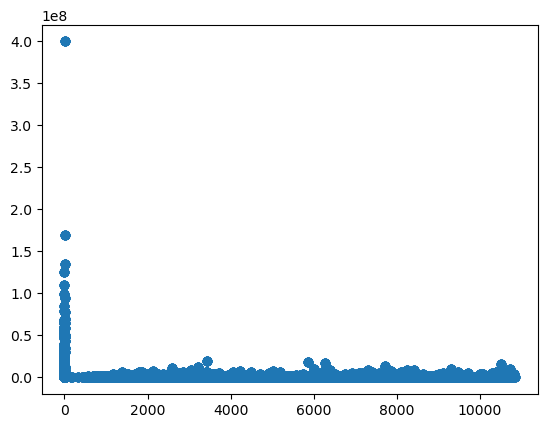

In [6]:
plt.scatter(dff['lot_area'],dff['price'])
plt.show()

In [7]:
dff.loc[dff['lot_area'] < 3, 'lot_area'] = dff['lot_area'] * 43560 # 1 acre = 43,560 sqft

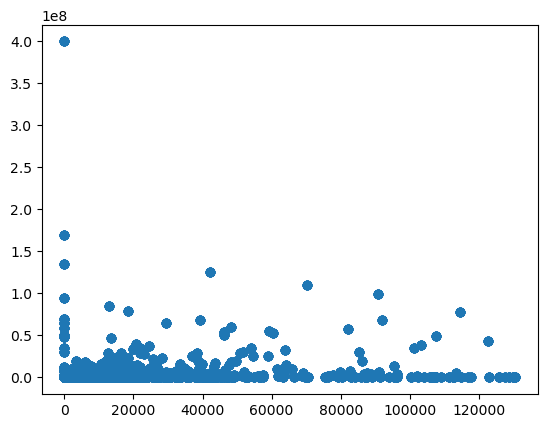

In [8]:
plt.scatter(dff['lot_area'],dff['price'])
plt.show()

Handling missing values

,Total,Percent
zestimate,15716,37.793382
rent_zestimate,10484,25.211620
lot_area_unit,6185,14.873509
lot_area,6185,14.873509
tax_assessed_value,4423,10.636302
is_fsba,4291,10.318873
broker_name,1857,4.465660
days_on_zillow,1450,3.486918
living_area,1092,2.626010
bathrooms,480,1.154290


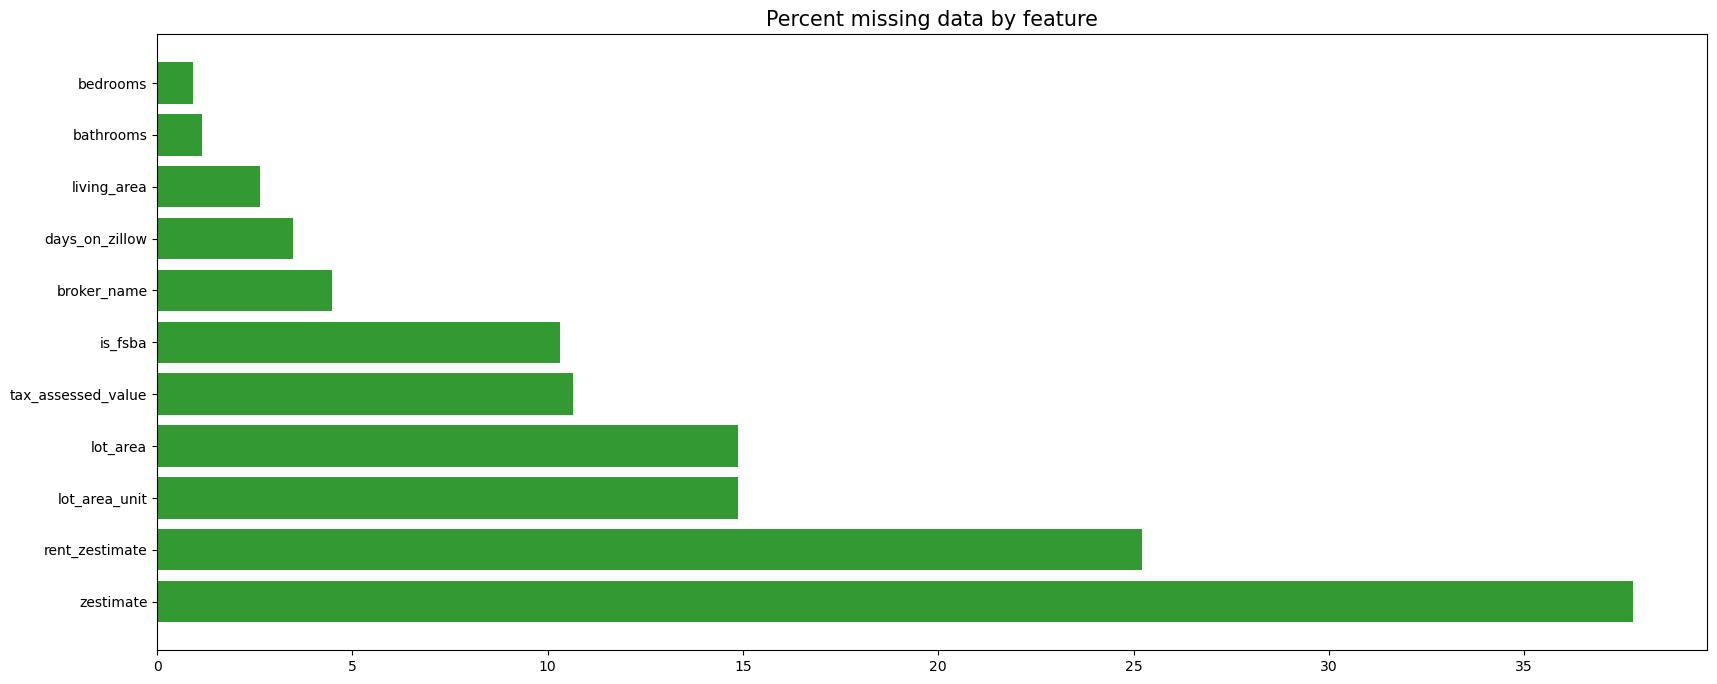

In [9]:
def missingData(data):
    total = data.isnull().sum().sort_values(ascending = False)
    percent = (data.isnull().sum()/data.isnull().count()*100).sort_values(ascending = False)
    md = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    md = md[md["Percent"] > 0]
    plt.figure(figsize = (20, 8))
    plt.barh(md.index, md["Percent"],color="g",alpha=0.8)
    plt.title('Percent missing data by feature', fontsize=15)
    return md
missingData(dff)

We see that bathrooms , living_area , bedrooms , is_fsba , lot_area , lot_area_unit , tax_assessed_value have low percent missing (10%) ,  so we just fill them.


In [12]:
#Delete missing lines less than 2%
dff = dff.dropna(subset=['bedrooms', 'living_area', 'bathrooms'])

In [ ]:
dff = dff.drop(columns=['broker_name', 'lot_area_unit'])

In [ ]:

dff['is_fsba'] = dff['is_fsba'].fillna(False)

#fill  with  mean value
cols_median = ['lot_area', 'tax_assessed_value', 'rent_zestimate']
dff[cols_median] = dff[cols_median].fillna(dff[cols_median].median())


Besides , zestimate has high percent mising .Therefore , we use KNN to impute the missing value.

In [15]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# B1: Lọc ra các cột số quan trọng để KNN dùng làm cơ sở "đoán" zestimate
# (Lưu ý: Bạn phải đảm bảo các cột này đã sạch NaN trước đó, ngoại trừ zestimate)
numeric_cols = ['price', 'bathrooms', 'bedrooms', 'living_area', 'lot_area', 'tax_assessed_value', 'zestimate']
df_knn = dff[numeric_cols].copy()

# B2: Chuẩn hóa dữ liệu (Đưa tất cả về thang đo từ 0 đến 1)
scaler = MinMaxScaler()
df_knn_scaled = pd.DataFrame(scaler.fit_transform(df_knn), columns=numeric_cols)

# B3: Khởi tạo và chạy KNN Imputer 
# n_neighbors=5: Tìm 5 căn nhà "hàng xóm" giống nhất để lấy trung bình
imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_knn_scaled), columns=numeric_cols)

# B4: Đảo ngược quá trình chuẩn hóa để đưa zestimate về lại con số tiền đô ($) thực tế
df_knn_final = pd.DataFrame(scaler.inverse_transform(df_knn_imputed), columns=numeric_cols)

# B5: Lấy cột zestimate đã điền hoàn chỉnh đắp ngược lại vào bộ dữ liệu gốc của mày
dff['zestimate'] = df_knn_final['zestimate']

Text(0.5, 1.0, 'Percent missing data by feature')

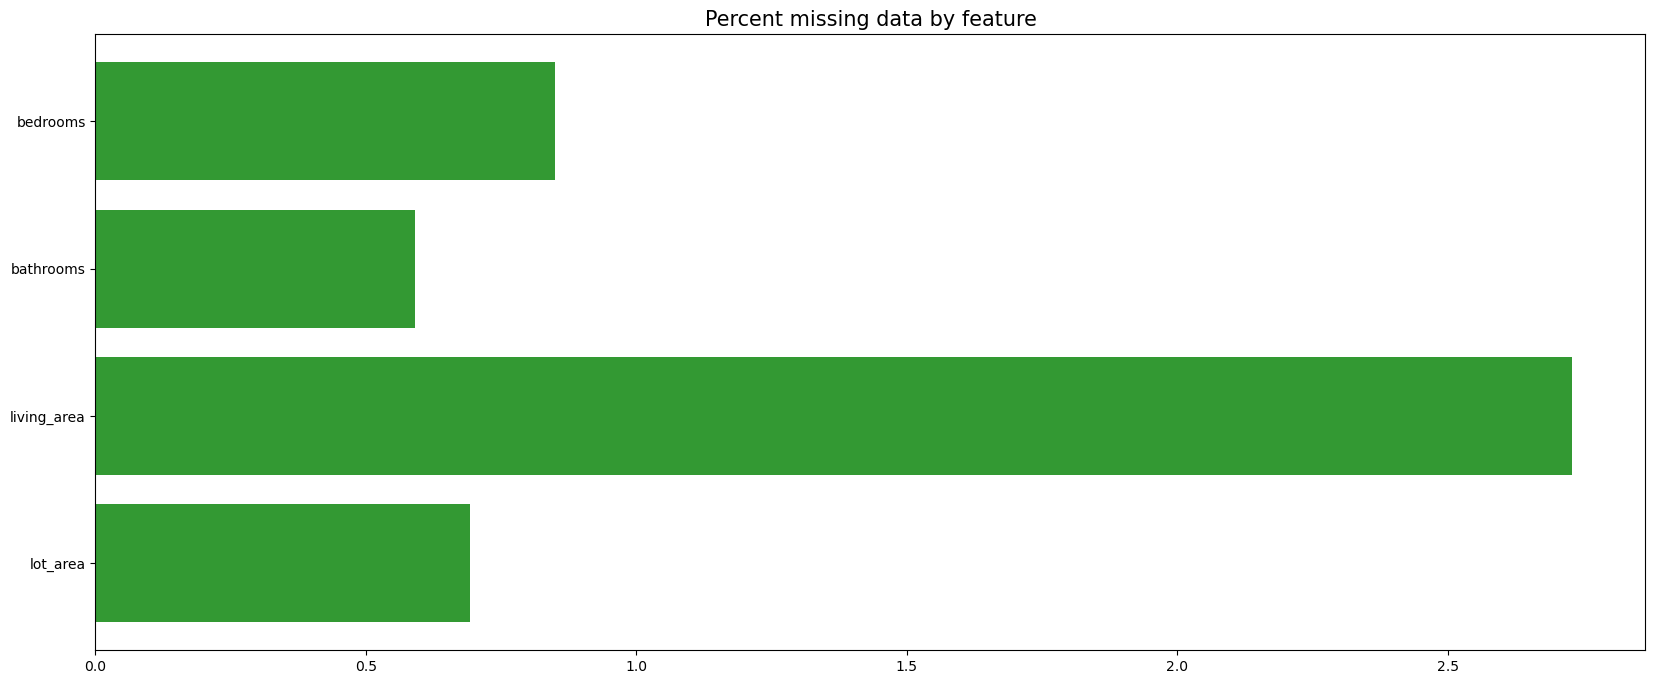

In [17]:
#list of columns that contain 0 as missing values
col_contains_0=['lot_area', 'living_area','bathrooms','bedrooms']
lists = []
for i in col_contains_0:
  lists.append([i,dff[dff[i]==0][i].count()/dff.shape[0]*100])
new_df = pd.DataFrame(lists, columns = ['Feature','Percentage of null'])
new_df
plt.figure(figsize = (20, 8))
plt.barh(new_df['Feature'], new_df["Percentage of null"],color="g",alpha=0.8)
plt.title('Percent missing data by feature', fontsize=15)

In [18]:
# 1. Soi xem những bất động sản có 0 phòng ngủ thuộc LOẠI (type) nào
print("--- Thống kê loại nhà có 0 phòng ngủ ---")
print(dff[dff['bedrooms'] == 0]['type'].value_counts())

print("\n") # In xuống dòng cho dễ nhìn

# 2. In thử 10 dòng đầu tiên ra để soi bằng mắt (xem diện tích, giá, loại nhà)
print("--- Chi tiết 10 căn có 0 phòng ngủ ---")
cols_to_check = ['type', 'price', 'living_area', 'lot_area', 'bedrooms', 'bathrooms']
display(dff[dff['bedrooms'] == 0][cols_to_check].head(10))

--- Thống kê loại nhà có 0 phòng ngủ ---
type
CONDO            85
SINGLE_FAMILY    47
LOT               9
Name: count, dtype: int64


--- Chi tiết 10 căn có 0 phòng ngủ ---


,type,price,living_area,lot_area,bedrooms,bathrooms
5083,SINGLE_FAMILY,440000.0,0.0,2495.9880,0.0,1.0
5174,SINGLE_FAMILY,1188000.0,985.0,1019.3040,0.0,2.0
5184,CONDO,146947.0,671.0,4.8951,0.0,1.0
5291,CONDO,499000.0,494.0,0.0000,0.0,1.0
5317,SINGLE_FAMILY,799000.0,966.0,2495.9880,0.0,1.0
5322,SINGLE_FAMILY,619000.0,825.0,2343.5280,0.0,1.0
5397,CONDO,450000.0,592.0,NaN,0.0,1.0
5407,CONDO,349617.0,326.0,12510.4320,0.0,1.0
5430,SINGLE_FAMILY,499000.0,0.0,1581.2280,0.0,1.0
5440,CONDO,359950.0,0.0,7498.0000,0.0,1.0


In [19]:
# 1a. Xử lý cột 'bedrooms': Ép thành NaN NẾU nó là nhà SINGLE_FAMILY có 0 phòng ngủ
dff.loc[(dff['type'] == 'SINGLE_FAMILY') & (dff['bedrooms'] == 0), 'bedrooms'] = np.nan

# 1b. Xử lý cột 'living_area' và 'lot_area': Ép TẤT CẢ số 0 thành NaN (vì diện tích không thể bằng 0)
dff['living_area'] = dff['living_area'].replace(0, np.nan)
dff['lot_area'] = dff['lot_area'].replace(0, np.nan)


# BƯỚC 2: Điền bù (Impute) các ô NaN vừa tạo ra

# Nhớ lại quy tắc: Khuyết dưới 2% thì XÓA (Drop), khuyết nhiều thì ĐIỀN (Impute)
# 'living_area' và 'bedrooms' đang khuyết rất ít (< 2%), nên xóa dòng cho sạch
dff = dff.dropna(subset=['bedrooms', 'living_area'])

# 'lot_area' khuyết nhiều hơn, nên ta điền bằng Trung vị (Median)
dff['lot_area'] = dff['lot_area'].fillna(dff['lot_area'].median())

In [20]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16115 entries, 0 to 18008
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price                  16115 non-null  float64
 1   status                 16115 non-null  object 
 2   type                   16115 non-null  object 
 3   has_add_attributions   16115 non-null  object 
 4   city                   16115 non-null  object 
 5   state                  16115 non-null  object 
 6   latitude               16115 non-null  float64
 7   longitude              16115 non-null  float64
 8   bathrooms              16115 non-null  float64
 9   bedrooms               16115 non-null  float64
 10  living_area            16115 non-null  float64
 11  lot_area               16115 non-null  float64
 12  lot_area_unit          14896 non-null  object 
 13  tax_assessed_value     14906 non-null  float64
 14  zestimate              14822 non-null  float64
 15  rent_ze

Remove duplicate records with same longitude and latitude

In [23]:
# Tự động tìm và xóa sạch các dòng trùng lặp 100% trong nháy mắt
dff = dff.drop_duplicates(keep='first')

# Và nhớ reset index lại cho đẹp đội hình sau khi xóa xong
dff = dff.reset_index(drop=True)

In [24]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16115 entries, 0 to 16114
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price                  16115 non-null  float64
 1   status                 16115 non-null  object 
 2   type                   16115 non-null  object 
 3   has_add_attributions   16115 non-null  object 
 4   city                   16115 non-null  object 
 5   state                  16115 non-null  object 
 6   latitude               16115 non-null  float64
 7   longitude              16115 non-null  float64
 8   bathrooms              16115 non-null  float64
 9   bedrooms               16115 non-null  float64
 10  living_area            16115 non-null  float64
 11  lot_area               16115 non-null  float64
 12  lot_area_unit          14896 non-null  object 
 13  tax_assessed_value     14906 non-null  float64
 14  zestimate              14822 non-null  float64
 15  re

In [25]:
dff.head()

,price,status,type,has_add_attributions,city,state,latitude,longitude,bathrooms,bedrooms,living_area,lot_area,lot_area_unit,tax_assessed_value,zestimate,rent_zestimate,is_fsba,is_non_owner_occupied,days_on_zillow
0,4980000.0,House for sale,SINGLE_FAMILY,True,West Hollywood,CA,34.100803,-118.380570,5.0,4.0,4126.0,4922.000,sqft,NaN,4758500.0,7151.0,True,True,7.908150e+08
1,1215000.0,House for sale,SINGLE_FAMILY,True,Woodland Hills,CA,34.180298,-118.642500,2.0,3.0,1825.0,7840.800,sqft,1170450.0,1144600.0,5245.0,True,True,1.020029e+09
2,2629000.0,House for sale,SINGLE_FAMILY,True,Beverly Hills,CA,34.112854,-118.433876,4.0,4.0,3019.0,43381.404,acres,1838782.0,2496200.0,8277.0,True,True,4.203270e+08
3,400000.0,Multi-family home for sale,MULTI_FAMILY,True,Los Angeles,CA,33.978700,-118.295680,2.0,3.0,944.0,4268.880,sqft,33757.0,830100.0,3089.0,True,True,9.995380e+08
4,849000.0,House for sale,SINGLE_FAMILY,True,San Pedro,CA,33.713604,-118.291880,2.0,2.0,1154.0,5002.000,sqft,756967.0,1036200.0,3414.0,True,True,6.436090e+08


In [26]:
# Chia cho 86,400,000 để đổi từ mili-giây sang ngày
dff['days_on_zillow'] = dff['days_on_zillow'] / 86400000

# (Tùy chọn) Làm tròn lại lấy 1 chữ số thập phân cho gọn mắt
dff['days_on_zillow'] = dff['days_on_zillow'].round(1)

In [27]:
dff.head()

,price,status,type,has_add_attributions,city,state,latitude,longitude,bathrooms,bedrooms,living_area,lot_area,lot_area_unit,tax_assessed_value,zestimate,rent_zestimate,is_fsba,is_non_owner_occupied,days_on_zillow
0,4980000.0,House for sale,SINGLE_FAMILY,True,West Hollywood,CA,34.100803,-118.380570,5.0,4.0,4126.0,4922.000,sqft,NaN,4758500.0,7151.0,True,True,9.2
1,1215000.0,House for sale,SINGLE_FAMILY,True,Woodland Hills,CA,34.180298,-118.642500,2.0,3.0,1825.0,7840.800,sqft,1170450.0,1144600.0,5245.0,True,True,11.8
2,2629000.0,House for sale,SINGLE_FAMILY,True,Beverly Hills,CA,34.112854,-118.433876,4.0,4.0,3019.0,43381.404,acres,1838782.0,2496200.0,8277.0,True,True,4.9
3,400000.0,Multi-family home for sale,MULTI_FAMILY,True,Los Angeles,CA,33.978700,-118.295680,2.0,3.0,944.0,4268.880,sqft,33757.0,830100.0,3089.0,True,True,11.6
4,849000.0,House for sale,SINGLE_FAMILY,True,San Pedro,CA,33.713604,-118.291880,2.0,2.0,1154.0,5002.000,sqft,756967.0,1036200.0,3414.0,True,True,7.4


In [28]:
dff.to_csv('zillow_preprocessed.csv' , index=False)